<a href="https://colab.research.google.com/github/vaisshnavee1410/Association_rules.ipynb/blob/main/Association_Rules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ASSOCIATION RULES**

###  **OBJECTIVE:**

The Objective of this assignment is to introduce students to rule mining techniques, particularly focusing on market basket analysis and provide hands on experience.

### **DATASET:**

* **Use the Online retail dataset to apply the association rules**

In [ ]:
import pandas as pd

#load the dataset
df = pd.read_excel('Online retail.xlsx')
df.head()

,"shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil"
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt


#### **Data Preprocessing:**

* **Pre-process the dataset to ensure it is suitable for Association rules, this may include handling missing values, removing duplicates, and converting the data to appropriate format.**

In [ ]:
# Reload the dataset with no headers (since the original data does not have column names)
df = pd.read_excel("Online retail.xlsx", header=None)

# Step 1: Drop missing values (empty rows)
df.dropna(inplace=True)

# Step 2: Strip extra spaces and split transactions into lists
transactions = df[0].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip() != ''])

# Step 3: Remove duplicate items within each transaction
transactions = transactions.apply(lambda x: list(set(x)))

# Step 4: Remove duplicate transactions (if any)
transactions = transactions.drop_duplicates()

# Show cleaned sample transactions
transactions.head()

,0
0,"[olive oil, almonds, green tea, antioxydant ju..."
1,"[eggs, meatballs, burgers]"
2,[chutney]
3,"[avocado, turkey]"
4,"[mineral water, whole wheat rice, milk, green ..."


#### **Association Rule Mining:**

* **Implement an Apriori algorithm using tool like python with libraries such as Pandas and Mlxtend etc.**

In [ ]:
!pip install mlxtend

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Load data
df = pd.read_excel("Online retail.xlsx", header=None)

# Preprocess data
df.dropna(inplace=True)
transactions = df[0].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()])
transactions = transactions.apply(lambda x: list(set(x)))
transactions = transactions.drop_duplicates()
transactions_list = transactions.tolist()

# Transaction encoding
te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Apriori algorithm
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

# Association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

# Output rules
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

      antecedents  consequents   support  confidence      lift
0     (chocolate)    (burgers)  0.024627    0.120608  1.055984
1       (burgers)  (chocolate)  0.024627    0.215620  1.055984
2          (eggs)    (burgers)  0.036261    0.174278  1.525892
3       (burgers)       (eggs)  0.036261    0.317487  1.525892
4  (french fries)    (burgers)  0.029475    0.152918  1.338872


* **Apply association rule mining techniques to the pre-processed dataset to discover interesting relationships between products purchased together.**

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Load the dataset
df = pd.read_excel("Online retail.xlsx", header=None)

# Step 2: Preprocess the data
df.dropna(inplace=True)
transactions = df[0].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()])
transactions = transactions.apply(lambda x: list(set(x)))  # Remove duplicate items per transaction
transactions = transactions.drop_duplicates()              # Remove duplicate transactions

# Step 3: One-hot encode the transactions
te = TransactionEncoder()
te_ary = te.fit(transactions.tolist()).transform(transactions.tolist())
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Step 4: Apply Apriori to find frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

# Step 5: Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Step 6: Filter rules for better lift and confidence
filtered_rules = rules[(rules['lift'] > 1.2) & (rules['confidence'] > 0.4)]

# Step 7: Display interesting rules
print(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='lift', ascending=False).head(10))

                     antecedents      consequents   support  confidence  \
38  (mineral water, ground beef)      (spaghetti)  0.024821    0.421053   
16                 (ground beef)      (spaghetti)  0.056040    0.411095   
27                        (soup)  (mineral water)  0.033547    0.471390   
40             (spaghetti, milk)  (mineral water)  0.022688    0.451737   
39      (spaghetti, ground beef)  (mineral water)  0.024821    0.442907   
23                   (olive oil)  (mineral water)  0.038782    0.440529   
15                 (ground beef)  (mineral water)  0.058949    0.432432   
36        (spaghetti, chocolate)  (mineral water)  0.023075    0.413194   
5                  (cooking oil)  (mineral water)  0.029087    0.403226   
37             (spaghetti, eggs)  (mineral water)  0.020748    0.402256   

        lift  
38  1.829291  
16  1.786031  
27  1.570385  
40  1.504916  
39  1.475497  
23  1.467575  
15  1.440603  
36  1.376514  
5   1.343305  
37  1.340073  


* **Set appropriate threshold for support, confidence and lift to extract meaning full rules.**

In [ ]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Load and preprocess dataset
df = pd.read_excel("Online retail.xlsx", header=None)
df.dropna(inplace=True)
transactions = df[0].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()])
transactions = transactions.apply(lambda x: list(set(x)))  # Remove duplicate items
transactions = transactions.drop_duplicates()

# One-hot encode
te = TransactionEncoder()
te_ary = te.fit(transactions.tolist()).transform(transactions.tolist())
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with support threshold
frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)

# Generate rules with confidence threshold
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

# Filter rules by lift threshold
meaningful_rules = rules[rules['lift'] >= 1.2]

# Display sorted rules
print(meaningful_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]
      .sort_values(by='lift', ascending=False)
      .head(10))

     antecedents      consequents   support  confidence      lift
1  (ground beef)      (spaghetti)  0.056040    0.411095  1.786031
3         (soup)  (mineral water)  0.033547    0.471390  1.570385
2    (olive oil)  (mineral water)  0.038782    0.440529  1.467575
0  (ground beef)  (mineral water)  0.058949    0.432432  1.440603


#### **Analysis and Interpretation:**

* **Analyse the generated rules to identify interesting patterns and relationships between the products.**

Top 10 Rules by Lift:
     antecedents      consequents   support  confidence      lift
1  (ground beef)      (spaghetti)  0.056040    0.411095  1.786031
3         (soup)  (mineral water)  0.033547    0.471390  1.570385
2    (olive oil)  (mineral water)  0.038782    0.440529  1.467575
0  (ground beef)  (mineral water)  0.058949    0.432432  1.440603


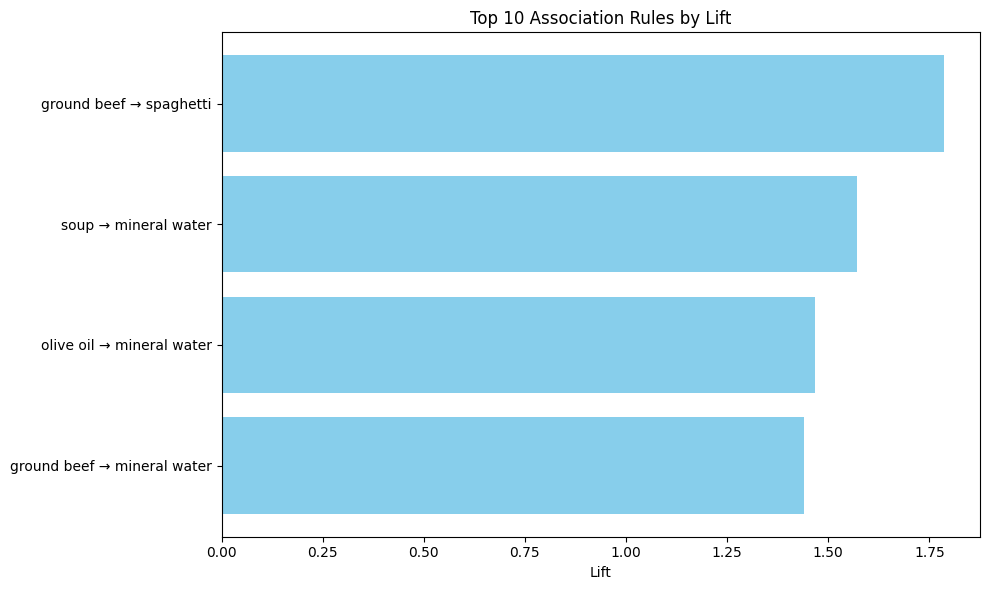

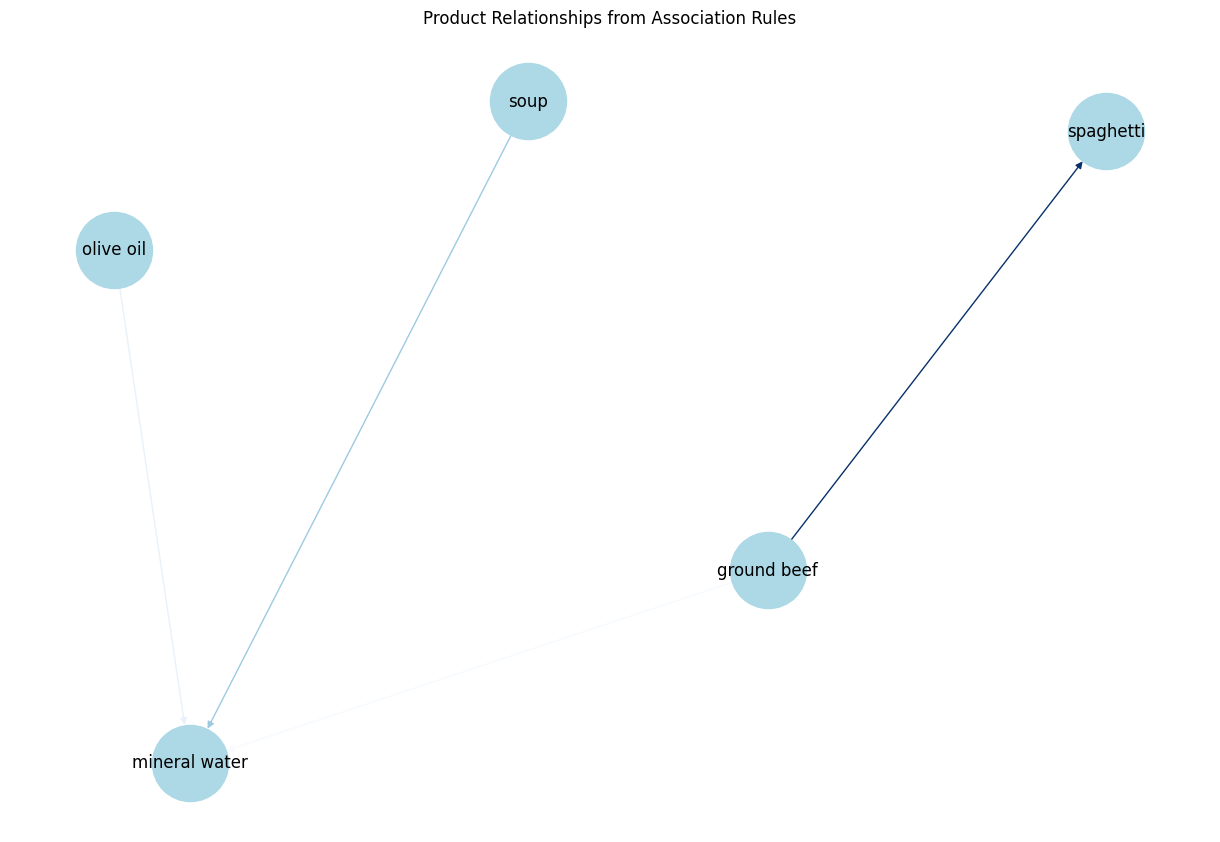

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# Load and preprocess dataset
df = pd.read_excel("Online retail.xlsx", header=None)
df.dropna(inplace=True)
transactions = df[0].apply(lambda x: [item.strip() for item in str(x).split(',') if item.strip()])
transactions = transactions.apply(lambda x: list(set(x)))  # Remove duplicate items
transactions = transactions.drop_duplicates()

# One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions.tolist()).transform(transactions.tolist())
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

# Generate frequent itemsets
frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)

# Generate association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
rules = rules[rules['lift'] >= 1.2]

# Sort and display top rules
top_rules = rules.sort_values(by='lift', ascending=False)
print("Top 10 Rules by Lift:")
print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

# Plot top 10 rules by lift
top10 = top_rules.head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top10)), top10['lift'], color='skyblue')
plt.yticks(range(len(top10)), [f"{', '.join(list(a))} → {', '.join(list(c))}"
                                for a, c in zip(top10['antecedents'], top10['consequents'])])
plt.xlabel("Lift")
plt.title("Top 10 Association Rules by Lift")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Create a network graph of relationships
G = nx.DiGraph()

for _, row in top10.iterrows():
    for ant in row['antecedents']:
        for con in row['consequents']:
            G.add_edge(ant, con, weight=row['lift'])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=1)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())
nx.draw(G, pos, node_color='lightblue', with_labels=True, node_size=3000, arrows=True, edge_color=weights, edge_cmap=plt.cm.Blues)
plt.title("Product Relationships from Association Rules")
plt.show()

* **Interpret the results and provide insights into customer purchasing behaviour based on the discovered rules.**

In [ ]:
import pandas as pd
from collections import Counter

# Load previously generated rules
# Assumes `rules` DataFrame already exists

# Extract most common products in antecedents and consequents
antecedent_items = [item for sublist in rules['antecedents'].apply(list) for item in sublist]
consequent_items = [item for sublist in rules['consequents'].apply(list) for item in sublist]

top_antecedents = Counter(antecedent_items).most_common(5)
top_consequents = Counter(consequent_items).most_common(5)

# Find top product pair by lift
top_rule = rules.sort_values(by='lift', ascending=False).iloc[0]
antecedent = ', '.join(list(top_rule['antecedents']))
consequent = ', '.join(list(top_rule['consequents']))

# Interpret results
print("Customer Purchase Insights:")

print("1. Most Frequently Appearing Antecedent Items (Products often leading to others):")
for item, count in top_antecedents:
    print(f"   - {item} (appears in {count} rules)")

print("\n2. Most Frequently Appearing Consequent Items (Products often bought as a result):")
for item, count in top_consequents:
    print(f"   - {item} (appears in {count} rules)")

print("\n3. Strongest Product Relationship:")
print(f"   - When customers buy [{antecedent}], they are likely to also buy [{consequent}].")
print(f"     → Support: {top_rule['support']:.2f}, Confidence: {top_rule['confidence']:.2f}, Lift: {top_rule['lift']:.2f}")

# Optional: Generate high-confidence rule summaries
print("\n4. High Confidence Rules (> 0.7):")
high_conf_rules = rules[rules['confidence'] > 0.7].sort_values(by='confidence', ascending=False)
for _, row in high_conf_rules.head(5).iterrows():
    ant = ', '.join(list(row['antecedents']))
    con = ', '.join(list(row['consequents']))
    print(f"   - Customers who buy [{ant}] also tend to buy [{con}] (confidence: {row['confidence']:.2f})")

Customer Purchase Insights:
1. Most Frequently Appearing Antecedent Items (Products often leading to others):
   - ground beef (appears in 2 rules)
   - olive oil (appears in 1 rules)
   - soup (appears in 1 rules)

2. Most Frequently Appearing Consequent Items (Products often bought as a result):
   - mineral water (appears in 3 rules)
   - spaghetti (appears in 1 rules)

3. Strongest Product Relationship:
   - When customers buy [ground beef], they are likely to also buy [spaghetti].
     → Support: 0.06, Confidence: 0.41, Lift: 1.79

4. High Confidence Rules (> 0.7):


### **INTERVIEW QUESTIONS:**

###  **What is lift and why is it important in Association rules?**

Lift is a crucial evaluation metric used in association rule mining to measure the strength of a rule beyond what is expected by random chance. In the context of market basket analysis, it tells us how much more likely two items are to be purchased together compared to if they were independent.

**Interpretation of Lift Values:**

	•	Lift > 1: There is a positive correlation between A and B. This means that the purchase of A increases the likelihood of purchasing B.
	•	Lift = 1: A and B are independent. The rule does not offer any valuable insight as both items occur together as expected by chance.
	•	Lift < 1: There is a negative correlation. Purchasing A makes it less likely that B will be purchased.


**Why Lift is Important:**

**1.	Highlights Strong Relationships:**

   Lift identifies meaningful patterns that might be hidden if we only looked at confidence or support. For example, even if a rule has high confidence, it may not be interesting if the consequent item is commonly purchased on its own.

**2.	Reduces False Positives:**

 It prevents misleading rules by adjusting for item popularity. A product that sells frequently will have high support, but that doesn’t mean it’s always associated with other products unless lift is also high.

**3.Business Applications: Rules with high lift can help in:**

•	Cross-selling (e.g., “customers who buy X are also likely to buy Y”),

•	Store layout optimization,

•	Targeted marketing strategies.


### **What is support and Confidence. How do you calculate them?**

In association rule mining, especially in retail or market basket analysis, the goal is to discover patterns in customer purchasing behavior by finding associations between items in large transaction datasets. Two of the most important metrics used to evaluate the strength and relevance of these patterns are Support and Confidence.

**1. Support:**

**Definition:**

Support measures the frequency or proportion of transactions in the dataset that contain a specific itemset. It tells us how popular or frequently occurring

**Explanation:**

•	Support helps in identifying rules that apply to a significant portion of the dataset.

•	If support is very low, the rule might be statistically insignificant even if it has high confidence.


**2.Confidence:**

**Definition:**

Confidence measures the likelihood that item B is purchased when item A is purchased. It indicates the reliability of the rule.

**Explanation:**


  •	Confidence is a conditional probability.

•	A higher confidence means that the rule A --> B is more likely to be true — i.e., customers who buy A often buy B as well.

**How are they calculated:**

In association rule mining, support and confidence are two key metrics used to evaluate the strength of a rule. Support is calculated by dividing the number of transactions that include both the antecedent and the consequent items by the total number of transactions. For example, if 100 out of 1,000 transactions contain both milk and bread, the support for the rule “milk ⇒ bread” would be 100 divided by 1,000, which equals 0.10 or 10%. This tells us how frequently the itemset appears in the dataset. On the other hand, confidence is calculated by dividing the number of transactions that contain both items by the number of transactions that contain only the antecedent. Continuing with the same example, if 150 transactions contain milk, and 100 of those also include bread, then the confidence for the rule “milk ⇒ bread” would be 100 divided by 150, which equals approximately 0.67 or 67%. This means that 67% of the time when customers buy milk, they also buy bread. Thus, support measures how common a rule is in general, while confidence measures how strong or reliable the rule is when the antecedent occurs.

### **What are some limitations or challenges of Association rules mining?**

Association Rule Mining is a powerful technique for discovering relationships between items in large datasets, especially in market basket analysis. However, despite its usefulness, it comes with several limitations and challenges:

**1.Large Number of Rules:**

One of the biggest challenges is that association rule mining can generate an overwhelming number of rules, especially when the dataset is large or when support and confidence thresholds are set too low. Most of these rules may be trivial, redundant, or irrelevant, making it difficult to extract meaningful insights without further filtering or ranking.


**2.Lack of Context or Semantics:**

Association rules only capture co-occurrence patterns; they do not understand why items are bought together. For example, the rule {milk} ⇒ {bread} tells us that they are frequently bought together, but not whether this is due to promotions, customer preferences, or seasonal trends. As a result, the rules may not always be actionable or interpretable in a real business context.


**3.No Temporal or Sequence Information:**

Traditional association rule mining ignores the order and time in which items are purchased. For example, it cannot distinguish between items bought in the same transaction versus across different visits. This makes it less useful for applications where sequence or timing matters, such as in customer journey analysis.


**4..Rare Item Problem:**

Items that are bought infrequently may still have strong associations with other items, but because their support is low, such patterns may be excluded from the results. This is known as the rare item problem. Balancing the support threshold to avoid missing important rare patterns while excluding noise is a common challenge.


**5.Computational Complexity:**

Mining association rules can be computationally intensive, particularly on large datasets with many unique items. Algorithms like Apriori require multiple passes through the dataset and can be slow or memory-intensive when the number of itemsets grows exponentially.


**6.Redundant and Irrelevant Rules:**

Many rules generated may be redundant (variations of the same rule) or not useful for decision-making. For example, a rule may be statistically significant but offer no new insight to a business. This requires additional post-processing such as pruning, lift filtering, or domain expert validation.